

EVENT: Russia_Ukraine

[Sample Size]
Pre-war: 120
Post-war: 131

[Return / Volatility]
         Event      Asset  Pre_Mean_Return  Post_Mean_Return  Pre_Volatility  Post_Volatility
Russia_Ukraine       Gold           0.0430           -0.0829          0.8558           0.9639
Russia_Ukraine        DXY           0.0330            0.0933          0.3351           0.5360
Russia_Ukraine USTreasury          -0.0443           -0.0640          0.3984           0.6534


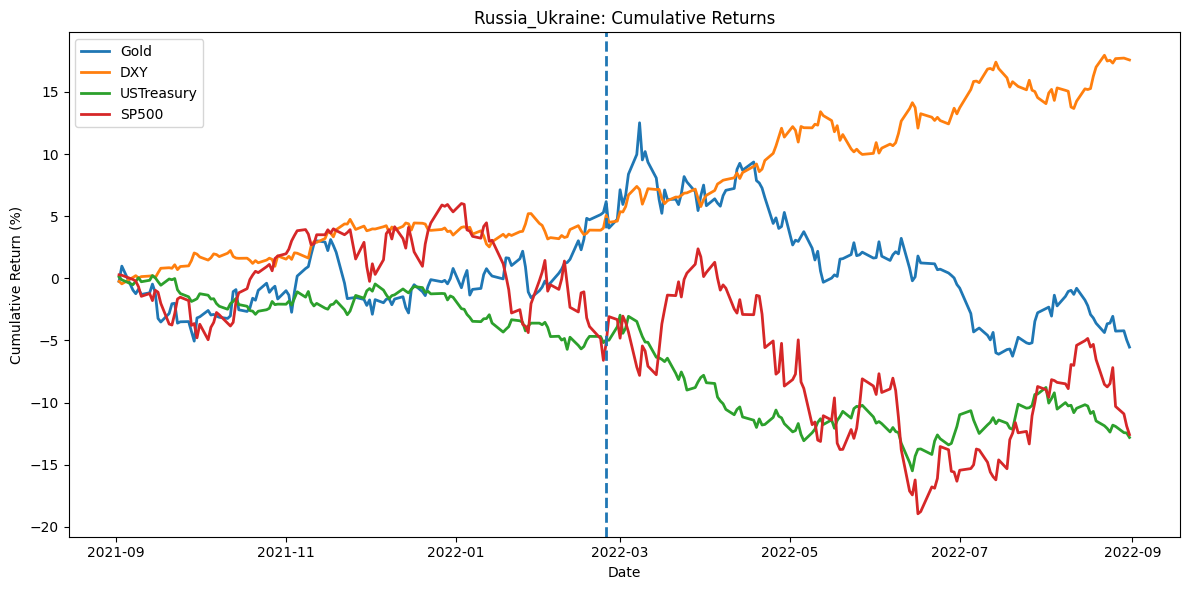

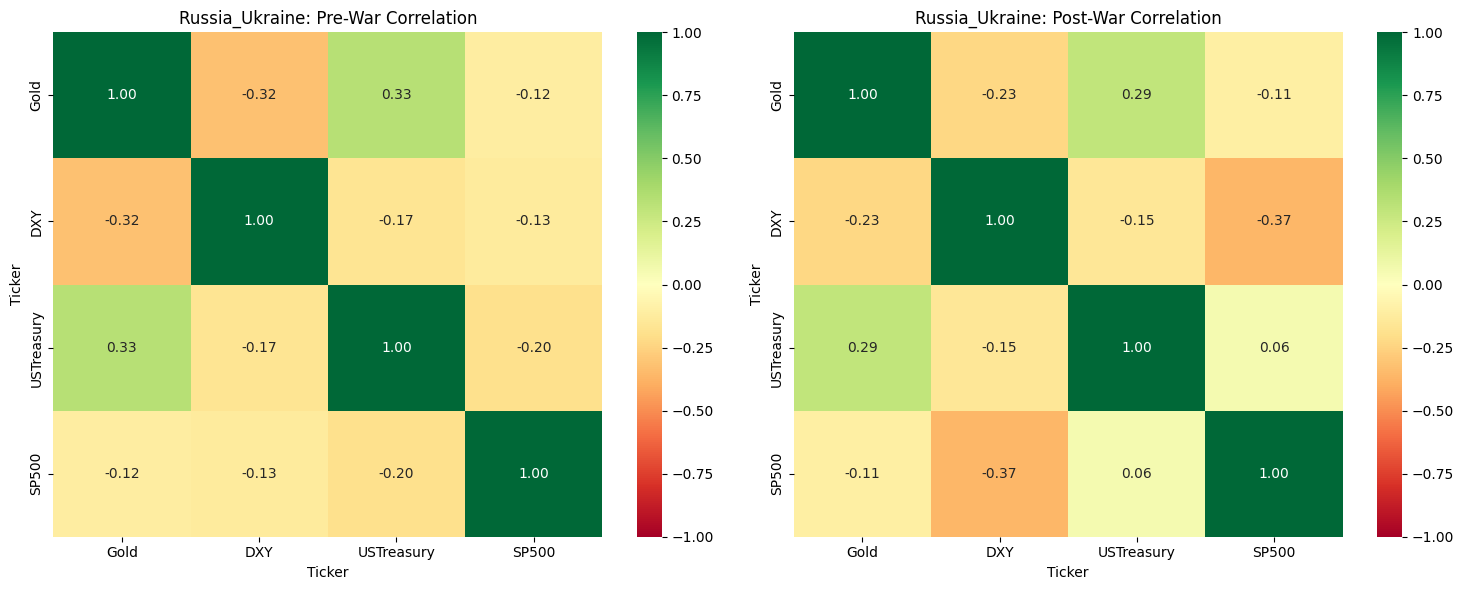


[S&P500 Correlation]
         Event      Asset  Pre_SP500_Correlation  Post_SP500_Correlation  Correlation_Change
Russia_Ukraine       Gold                -0.1164                 -0.1060              0.0104
Russia_Ukraine        DXY                -0.1287                 -0.3660             -0.2372
Russia_Ukraine USTreasury                -0.1952                  0.0593              0.2545


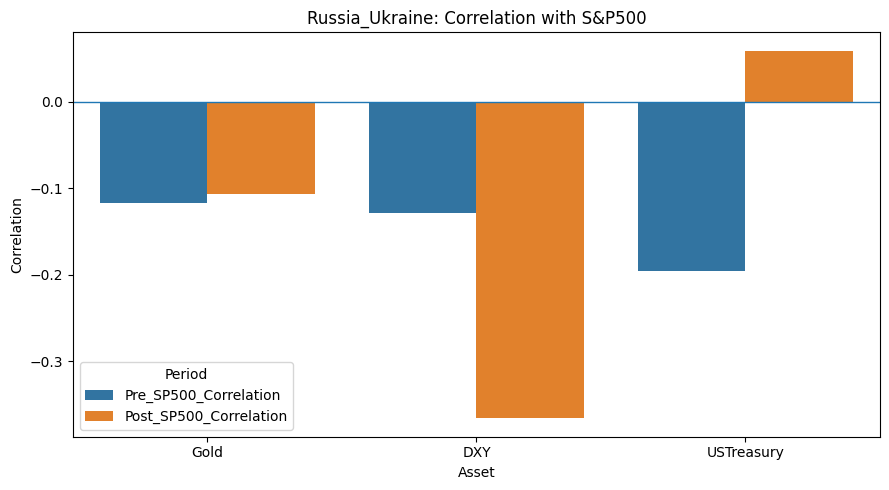


[VaR / Volatility]
         Event      Asset  VaR_Pre_95  VaR_Post_95  VaR_Risk_Change  Std_Pre  Std_Post
Russia_Ukraine       Gold     -1.6462      -1.6636           1.0578   0.8558    0.9639
Russia_Ukraine        DXY     -0.5009      -0.7863          56.9765   0.3351    0.5360
Russia_Ukraine USTreasury     -0.7353      -1.1241          52.8803   0.3984    0.6534


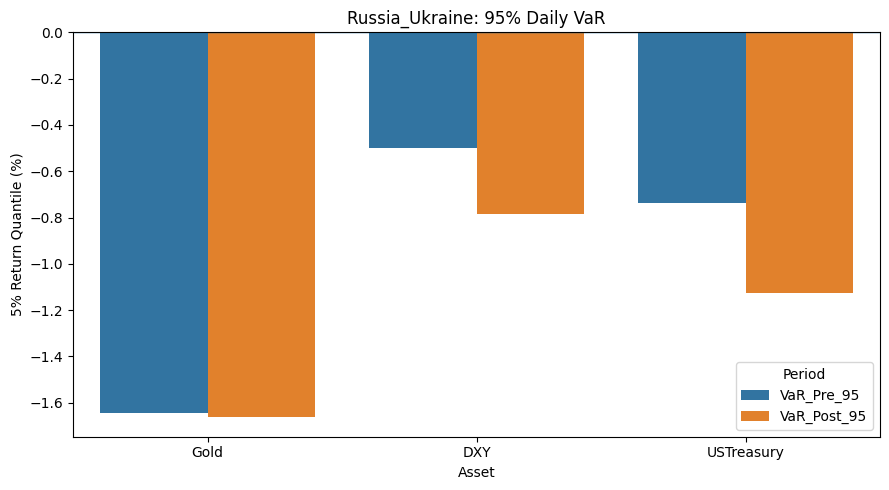

C:\Users\82109\AppData\Local\Temp\ipykernel_18824\2186388506.py:537: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  reg_data = pd.concat(



[OLS: Russia_Ukraine - Gold]
                            OLS Regression Results                            
Dep. Variable:                   Gold   R-squared:                       0.098
Model:                            OLS   Adj. R-squared:                  0.080
Method:                 Least Squares   F-statistic:                     4.492
Date:                Wed, 19 Aug 2026   Prob (F-statistic):           0.000618
Time:                        22:48:14   Log-Likelihood:                 835.73
No. Observations:                 251   AIC:                            -1659.
Df Residuals:                     245   BIC:                            -1638.
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
cons

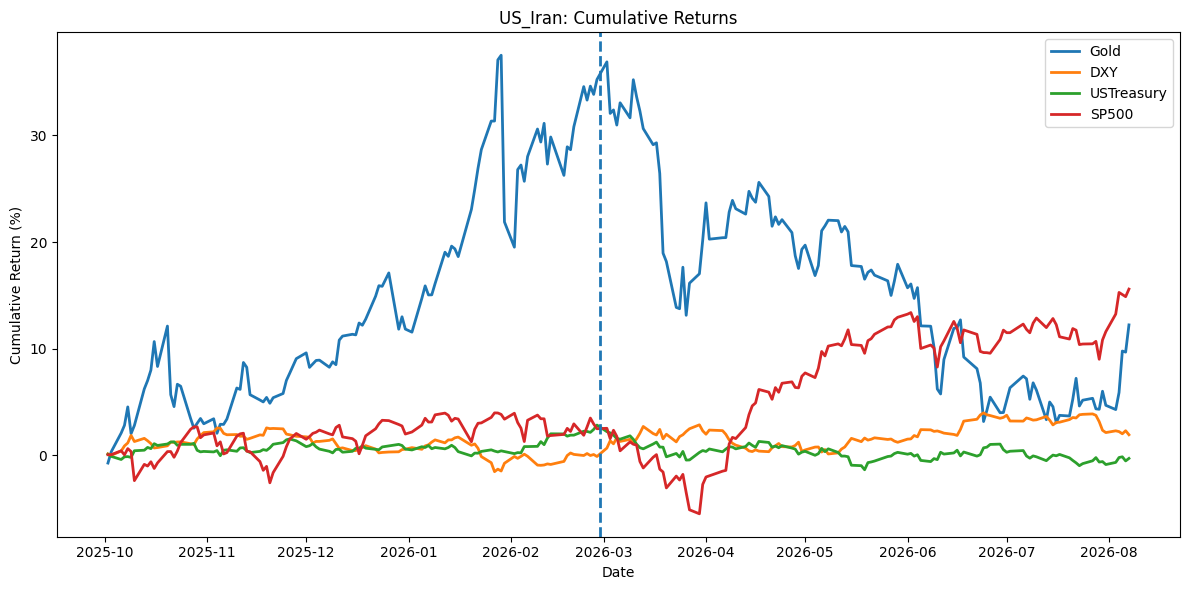

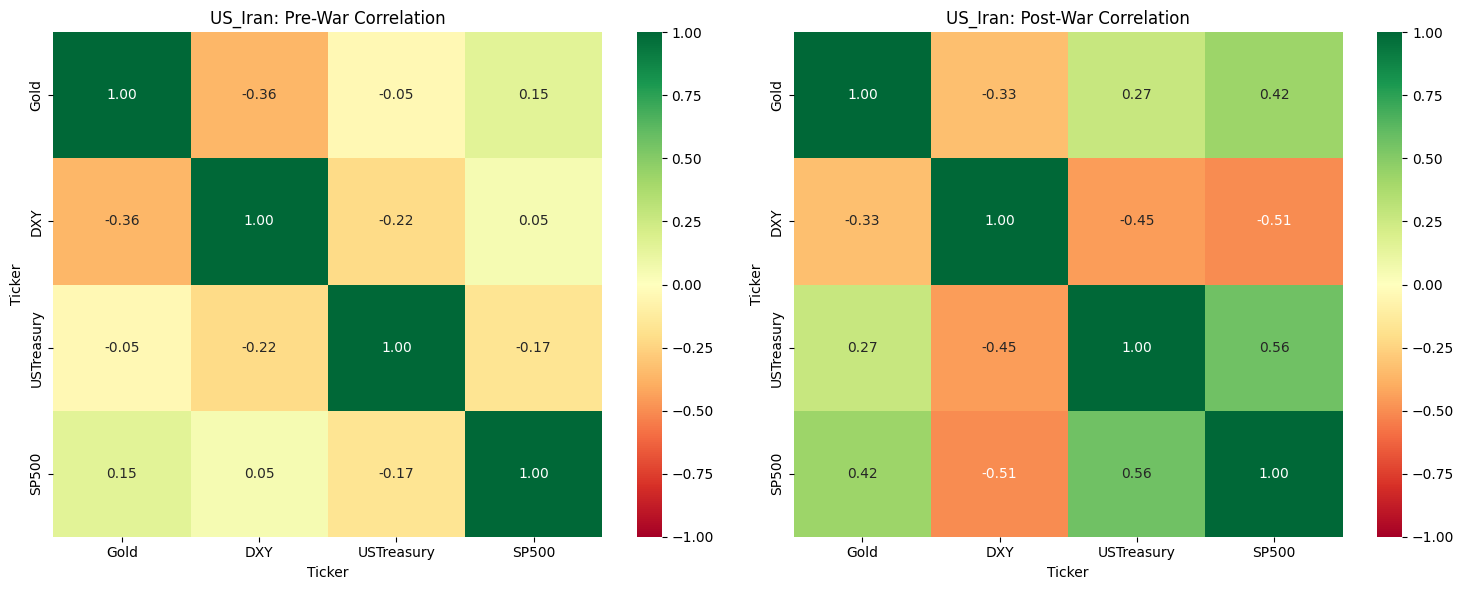


[S&P500 Correlation]
  Event      Asset  Pre_SP500_Correlation  Post_SP500_Correlation  Correlation_Change
US_Iran       Gold                 0.1539                  0.4221              0.2682
US_Iran        DXY                 0.0482                 -0.5069             -0.5551
US_Iran USTreasury                -0.1699                  0.5643              0.7342


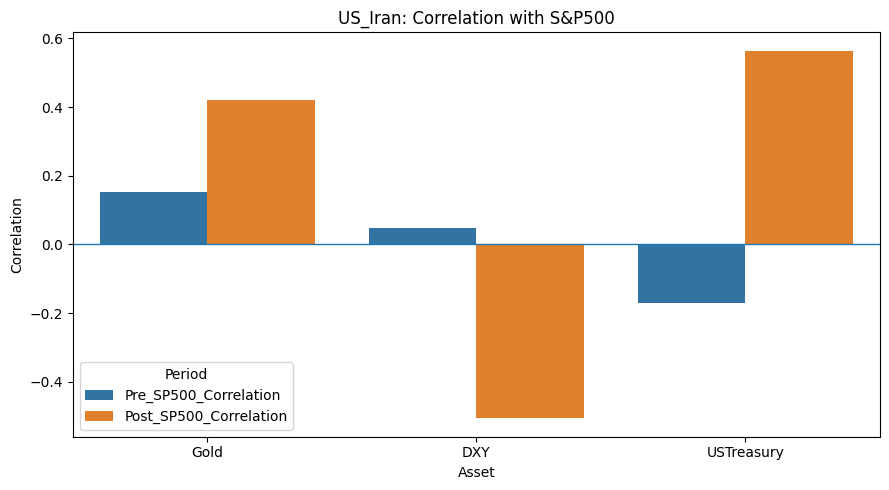


[VaR / Volatility]
  Event      Asset  VaR_Pre_95  VaR_Post_95  VaR_Risk_Change  Std_Pre  Std_Post
US_Iran       Gold     -2.7899      -3.2933          18.0448   2.1075    1.7411
US_Iran        DXY     -0.5617      -0.5612          -0.0832   0.3161    0.3460
US_Iran USTreasury     -0.3320      -0.5236          57.7060   0.2457    0.3294


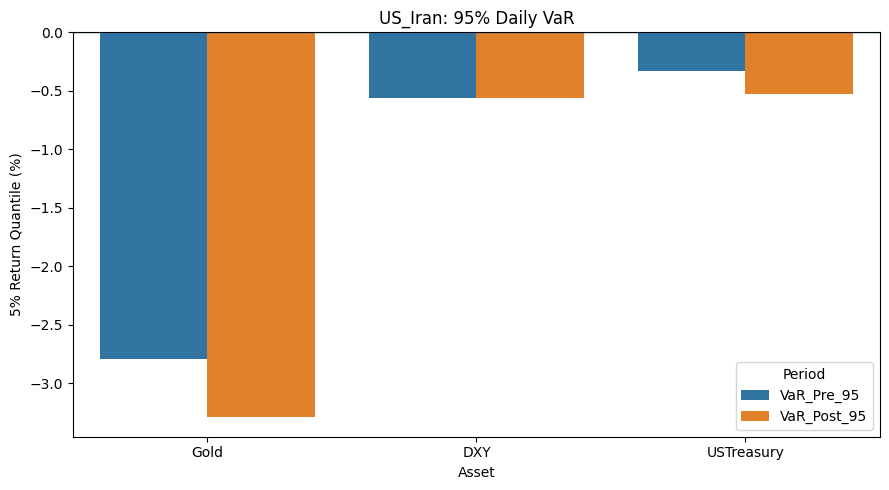

C:\Users\82109\AppData\Local\Temp\ipykernel_18824\2186388506.py:537: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  reg_data = pd.concat(



[OLS: US_Iran - Gold]
                            OLS Regression Results                            
Dep. Variable:                   Gold   R-squared:                       0.118
Model:                            OLS   Adj. R-squared:                  0.097
Method:                 Least Squares   F-statistic:                     6.663
Date:                Wed, 19 Aug 2026   Prob (F-statistic):           8.95e-06
Time:                        22:48:16   Log-Likelihood:                 548.96
No. Observations:                 212   AIC:                            -1086.
Df Residuals:                     206   BIC:                            -1066.
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const      

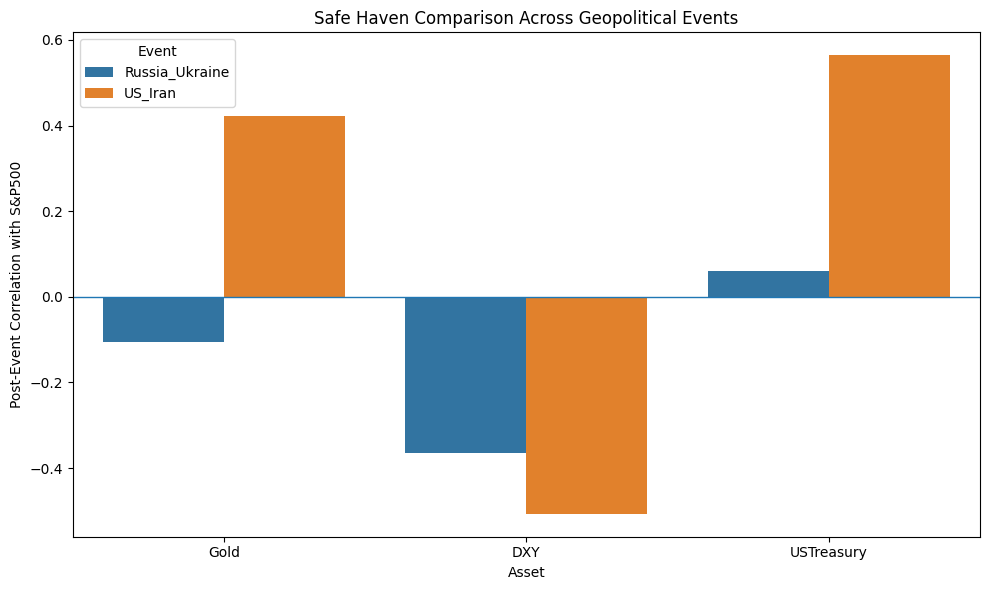


분석 완료


In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm


# 1. 사건 설정

events = {
    "Russia_Ukraine": {
        "start_date": "2021-09-01",
        "end_date": "2022-09-01",
        "event_date": "2022-02-24"
    },
    "US_Iran": {
        "start_date": "2025-10-01",
        "end_date": "2026-08-10",
        "event_date": "2026-02-28"
    }
}


# 2. 변수 설정

safe_haven_tickers = {
    "Gold": "GC=F",
    "DXY": "DX-Y.NYB",
    "USTreasury": "IEF"
}

benchmark_tickers = {
    "SP500": "^GSPC"
}

macro_tickers = {
    "VIX": "^VIX",
    "US10Y": "^TNX"
}


# 3. 데이터 다운로드 함수

def download_prices(ticker_dict, start, end):

    data = yf.download(
        list(ticker_dict.values()),
        start=start,
        end=end,
        auto_adjust=False,
        progress=False
    )

    if data.columns.nlevels > 1:

        if "Adj Close" in data.columns.get_level_values(0):
            prices = data["Adj Close"]
        else:
            prices = data["Close"]

    else:
        prices = data.copy()

    ticker_to_name = {
        ticker: name
        for name, ticker in ticker_dict.items()
    }

    prices = prices.rename(columns=ticker_to_name)
    prices = prices[list(ticker_dict.keys())]

    return prices


# 4. VaR 계산 함수

def calculate_var(return_series, confidence_level=0.95):

    return np.percentile(
        return_series.dropna(),
        (1 - confidence_level) * 100
    )


# 5. 사건별 분석 함수

def analyze_event(
    event_name,
    start_date,
    end_date,
    event_date
):

    event_date = pd.to_datetime(event_date)

    print("\n")
    print("=" * 60)
    print(f"EVENT: {event_name}")
    print("=" * 60)


    # 6. 데이터 다운로드

    safe_prices = download_prices(
        safe_haven_tickers,
        start_date,
        end_date
    )

    benchmark_prices = download_prices(
        benchmark_tickers,
        start_date,
        end_date
    )

    macro_data = download_prices(
        macro_tickers,
        start_date,
        end_date
    )


    # 7. 로그수익률 계산

    safe_returns = np.log(
        safe_prices / safe_prices.shift(1)
    )

    benchmark_returns = np.log(
        benchmark_prices / benchmark_prices.shift(1)
    )

    asset_returns = pd.concat(
        [
            safe_returns,
            benchmark_returns
        ],
        axis=1
    ).dropna()


    # 8. 누적수익률 계산

    cum_returns = (
        np.exp(asset_returns.cumsum())
        - 1
    )


    # 9. VIX 및 금리 변화량 계산

    macro_changes = pd.DataFrame(
        index=macro_data.index
    )

    macro_changes["VIX_diff"] = (
        macro_data["VIX"].diff()
    )

    macro_changes["Rate_diff"] = (
        macro_data["US10Y"].diff()
    )


    # 10. 전쟁 전후 구분

    pre_war = asset_returns[
        asset_returns.index < event_date
    ]

    post_war = asset_returns[
        asset_returns.index >= event_date
    ]

    print("\n[Sample Size]")
    print("Pre-war:", len(pre_war))
    print("Post-war:", len(post_war))


    # 11. 평균수익률 및 변동성

    comparison_results = []

    for asset in safe_haven_tickers.keys():

        comparison_results.append({

            "Event": event_name,
            "Asset": asset,

            "Pre_Mean_Return":
                pre_war[asset].mean() * 100,

            "Post_Mean_Return":
                post_war[asset].mean() * 100,

            "Pre_Volatility":
                pre_war[asset].std() * 100,

            "Post_Volatility":
                post_war[asset].std() * 100

        })

    return_df = pd.DataFrame(
        comparison_results
    )

    print("\n[Return / Volatility]")

    print(
        return_df.round(4).to_string(
            index=False
        )
    )


    # 12. 누적수익률 시각화

    plt.figure(
        figsize=(12, 6)
    )

    for asset in asset_returns.columns:

        plt.plot(
            cum_returns.index,
            cum_returns[asset] * 100,
            label=asset,
            linewidth=2
        )

    plt.axvline(
        event_date,
        linestyle="--",
        linewidth=2
    )

    plt.title(
        f"{event_name}: Cumulative Returns"
    )

    plt.xlabel("Date")
    plt.ylabel("Cumulative Return (%)")

    plt.legend()
    plt.tight_layout()

    plt.savefig(
        f"{event_name}_cumulative_returns.png",
        dpi=300
    )

    plt.show()


    # 13. 전체 상관관계

    pre_corr = pre_war.corr()
    post_corr = post_war.corr()

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(15, 6)
    )

    sns.heatmap(
        pre_corr,
        annot=True,
        fmt=".2f",
        center=0,
        vmin=-1,
        vmax=1,
        cmap="RdYlGn",
        ax=axes[0]
    )

    axes[0].set_title(
        f"{event_name}: Pre-War Correlation"
    )

    sns.heatmap(
        post_corr,
        annot=True,
        fmt=".2f",
        center=0,
        vmin=-1,
        vmax=1,
        cmap="RdYlGn",
        ax=axes[1]
    )

    axes[1].set_title(
        f"{event_name}: Post-War Correlation"
    )

    plt.tight_layout()

    plt.savefig(
        f"{event_name}_correlation.png",
        dpi=300
    )

    plt.show()


    # 14. S&P500과의 상관관계

    correlation_results = []

    for asset in safe_haven_tickers.keys():

        pre_sp_corr = (
            pre_war[asset]
            .corr(pre_war["SP500"])
        )

        post_sp_corr = (
            post_war[asset]
            .corr(post_war["SP500"])
        )

        correlation_results.append({

            "Event":
                event_name,

            "Asset":
                asset,

            "Pre_SP500_Correlation":
                pre_sp_corr,

            "Post_SP500_Correlation":
                post_sp_corr,

            "Correlation_Change":
                post_sp_corr - pre_sp_corr

        })

    correlation_df = pd.DataFrame(
        correlation_results
    )

    print("\n[S&P500 Correlation]")

    print(
        correlation_df.round(4).to_string(
            index=False
        )
    )


    # 15. S&P500 상관관계 시각화

    corr_plot = correlation_df.melt(

        id_vars=[
            "Event",
            "Asset"
        ],

        value_vars=[
            "Pre_SP500_Correlation",
            "Post_SP500_Correlation"
        ],

        var_name="Period",

        value_name="Correlation"
    )

    plt.figure(
        figsize=(9, 5)
    )

    sns.barplot(
        data=corr_plot,
        x="Asset",
        y="Correlation",
        hue="Period"
    )

    plt.axhline(
        0,
        linewidth=1
    )

    plt.title(
        f"{event_name}: Correlation with S&P500"
    )

    plt.ylabel("Correlation")

    plt.tight_layout()

    plt.savefig(
        f"{event_name}_sp500_correlation.png",
        dpi=300
    )

    plt.show()


    # 16. VaR 및 변동성

    var_results = []

    for asset in safe_haven_tickers.keys():

        var_pre = calculate_var(
            pre_war[asset]
        )

        var_post = calculate_var(
            post_war[asset]
        )

        std_pre = (
            pre_war[asset].std()
        )

        std_post = (
            post_war[asset].std()
        )

        if var_pre != 0:

            risk_change = (
                abs(var_post)
                / abs(var_pre)
                - 1
            ) * 100

        else:

            risk_change = np.nan


        var_results.append({

            "Event":
                event_name,

            "Asset":
                asset,

            "VaR_Pre_95":
                var_pre * 100,

            "VaR_Post_95":
                var_post * 100,

            "VaR_Risk_Change":
                risk_change,

            "Std_Pre":
                std_pre * 100,

            "Std_Post":
                std_post * 100

        })


    var_df = pd.DataFrame(
        var_results
    )

    print("\n[VaR / Volatility]")

    print(
        var_df.round(4).to_string(
            index=False
        )
    )


    # 17. VaR 시각화

    var_plot = var_df.melt(

        id_vars=[
            "Event",
            "Asset"
        ],

        value_vars=[
            "VaR_Pre_95",
            "VaR_Post_95"
        ],

        var_name="Period",

        value_name="VaR"
    )

    plt.figure(
        figsize=(9, 5)
    )

    sns.barplot(
        data=var_plot,
        x="Asset",
        y="VaR",
        hue="Period"
    )

    plt.axhline(
        0,
        linewidth=1
    )

    plt.title(
        f"{event_name}: 95% Daily VaR"
    )

    plt.ylabel(
        "5% Return Quantile (%)"
    )

    plt.tight_layout()

    plt.savefig(
        f"{event_name}_var.png",
        dpi=300
    )

    plt.show()


    # 18. 회귀분석 데이터 구성

    reg_data = pd.concat(
        [
            asset_returns,
            macro_changes
        ],
        axis=1
    ).dropna()


    # 19. 전쟁 더미변수

    reg_data["War_Dummy"] = (
        reg_data.index >= event_date
    ).astype(int)


    # 20. VIX 상호작용 변수

    reg_data["VIX_War_Interaction"] = (
        reg_data["VIX_diff"]
        * reg_data["War_Dummy"]
    )


    # 21. 자산별 회귀분석

    regression_results = {}
    regression_summary = []

    for asset in safe_haven_tickers.keys():

        y = reg_data[asset]

        X = reg_data[
            [
                "SP500",
                "VIX_diff",
                "Rate_diff",
                "War_Dummy",
                "VIX_War_Interaction"
            ]
        ]

        X = sm.add_constant(X)

        model = sm.OLS(
            y,
            X
        ).fit(
            cov_type="HC3"
        )

        regression_results[
            asset
        ] = model

        print(
            f"\n[OLS: {event_name} - {asset}]"
        )

        print(
            model.summary()
        )


        for variable in model.params.index:

            regression_summary.append({

                "Event":
                    event_name,

                "Asset":
                    asset,

                "Variable":
                    variable,

                "Coefficient":
                    model.params[variable],

                "P_Value":
                    model.pvalues[variable]

            })


    regression_df = pd.DataFrame(
        regression_summary
    )


    # 22. 사건별 결과 저장

    return_df.to_csv(
        f"{event_name}_return_volatility.csv",
        index=False
    )

    correlation_df.to_csv(
        f"{event_name}_sp500_correlation.csv",
        index=False
    )

    var_df.to_csv(
        f"{event_name}_var.csv",
        index=False
    )

    regression_df.to_csv(
        f"{event_name}_regression.csv",
        index=False
    )


    return {
        "return": return_df,
        "correlation": correlation_df,
        "var": var_df,
        "regression": regression_df
    }


# 23. 두 사건 분석 실행

all_results = {}

for event_name, settings in events.items():

    all_results[event_name] = analyze_event(

        event_name=event_name,

        start_date=settings["start_date"],

        end_date=settings["end_date"],

        event_date=settings["event_date"]
    )


# 24. 두 사건 결과 통합

all_returns = pd.concat(
    [
        result["return"]
        for result in all_results.values()
    ],
    ignore_index=True
)

all_correlations = pd.concat(
    [
        result["correlation"]
        for result in all_results.values()
    ],
    ignore_index=True
)

all_var = pd.concat(
    [
        result["var"]
        for result in all_results.values()
    ],
    ignore_index=True
)

all_regressions = pd.concat(
    [
        result["regression"]
        for result in all_results.values()
    ],
    ignore_index=True
)


# 25. 두 사건 비교 출력

print("\n[Event Comparison - Return / Volatility]")

print(
    all_returns.round(4).to_string(
        index=False
    )
)


print("\n[Event Comparison - S&P500 Correlation]")

print(
    all_correlations.round(4).to_string(
        index=False
    )
)


print("\n[Event Comparison - VaR]")

print(
    all_var.round(4).to_string(
        index=False
    )
)


print("\n[Event Comparison - Regression]")

print(
    all_regressions.round(5).to_string(
        index=False
    )
)


# 26. 통합 결과 저장

all_returns.to_csv(
    "ALL_event_return_volatility.csv",
    index=False
)

all_correlations.to_csv(
    "ALL_event_sp500_correlation.csv",
    index=False
)

all_var.to_csv(
    "ALL_event_var.csv",
    index=False
)

all_regressions.to_csv(
    "ALL_event_regression.csv",
    index=False
)


# 27. 사건별 Safe Haven 상관관계 비교 그래프

comparison_plot = all_correlations[
    [
        "Event",
        "Asset",
        "Post_SP500_Correlation"
    ]
]

plt.figure(
    figsize=(10, 6)
)

sns.barplot(
    data=comparison_plot,
    x="Asset",
    y="Post_SP500_Correlation",
    hue="Event"
)

plt.axhline(
    0,
    linewidth=1
)

plt.title(
    "Safe Haven Comparison Across Geopolitical Events"
)

plt.ylabel(
    "Post-Event Correlation with S&P500"
)

plt.tight_layout()

plt.savefig(
    "ALL_event_safe_haven_comparison.png",
    dpi=300
)

plt.show()


print("\n분석 완료")

[*********************100%***********************]  4 of 4 completed


 [러-우 전쟁] 전후 리스크 지표 비교 (기준일: 2022-02-24)
Asset VaR_Pre VaR_Post Risk_Inc Std_Pre Std_Post
 Gold  -1.65%   -1.66%    1.06%   0.86%    0.96%
US10Y  -4.57%   -3.81%  -16.59%   3.07%    3.03%
  DXY  -0.50%   -0.79%   56.98%   0.34%    0.54%
  VIX -12.09%   -9.50%  -21.40%   9.17%    7.15%


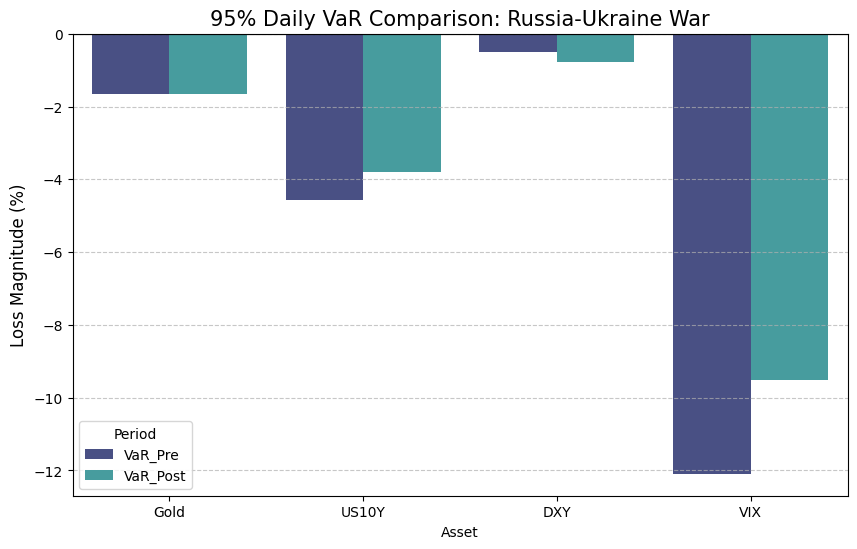

In [5]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 데이터 설정 및 다운로드
tickers = {'Gold': 'GC=F', 'US10Y': '^TNX', 'DXY': 'DX-Y.NYB', 'VIX': '^VIX'}
start_date, end_date, war_date = "2021-09-01", "2022-09-01", "2022-02-24"

all_data = yf.download(list(tickers.values()), start=start_date, end=end_date)
raw_data = all_data['Adj Close'] if 'Adj Close' in all_data.columns.get_level_values(0) else all_data['Close']
raw_data = raw_data.rename(columns={v: k for k, v in tickers.items()})[list(tickers.keys())]

# 2. 수익률 및 데이터 분할 (핵심 수정 부분)
returns = np.log(raw_data / raw_data.shift(1)).dropna()
pre_war = returns.loc[:pd.to_datetime(war_date) - pd.Timedelta(days=1)]
post_war = returns.loc[war_date:]

# 3. VaR 계산 함수
def calculate_var(series, confidence=0.95):
    return np.percentile(series, (1 - confidence) * 100)

# 4. 리스크 지표 통합 계산
var_results = []
for asset in returns.columns:
    v_pre, v_post = calculate_var(pre_war[asset]), calculate_var(post_war[asset])
    s_pre, s_post = pre_war[asset].std(), post_war[asset].std()
    
    var_results.append({
        'Asset': asset,
        'VaR_Pre': v_pre * 100,      # 숫자로 저장 (그래프용)
        'VaR_Post': v_post * 100,    # 숫자로 저장 (그래프용)
        'Risk_Inc': (v_post / v_pre - 1) * 100 if v_pre != 0 else 0,
        'Std_Pre': s_pre * 100,
        'Std_Post': s_post * 100
    })

var_df = pd.DataFrame(var_results)

# 5. 결과 출력 (표 제공)
print("\n" + "="*65)
print(f" [러-우 전쟁] 전후 리스크 지표 비교 (기준일: {war_date})")
print("="*65)
display_df = var_df.copy()
for col in ['VaR_Pre', 'VaR_Post', 'Risk_Inc', 'Std_Pre', 'Std_Post']:
    display_df[col] = display_df[col].map("{:.2f}%".format)
print(display_df.to_string(index=False))

# 6. 시각화 (그래프 수정)
plt.figure(figsize=(10, 6))
var_plot_data = var_df.melt(id_vars='Asset', value_vars=['VaR_Pre', 'VaR_Post'], 
                            var_name='Period', value_name='Loss_Pct')

sns.barplot(data=var_plot_data, x='Asset', y='Loss_Pct', hue='Period', palette='mako')
plt.title(f'95% Daily VaR Comparison: Russia-Ukraine War', fontsize=15)
plt.ylabel('Loss Magnitude (%)', fontsize=12)
plt.axhline(0, color='black', linewidth=0.8)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('var_analysis_fixed.png', dpi=300)
plt.show()



EVENT: Russia_Ukraine

[Sample Size]
Pre-war: 120
Post-war: 131

[Return / Volatility]
         Event      Asset  Pre_Mean_Return  Post_Mean_Return  Pre_Volatility  Post_Volatility
Russia_Ukraine       Gold           0.0430           -0.0829          0.8558           0.9639
Russia_Ukraine        DXY           0.0330            0.0933          0.3351           0.5360
Russia_Ukraine USTreasury          -0.0443           -0.0640          0.3984           0.6534


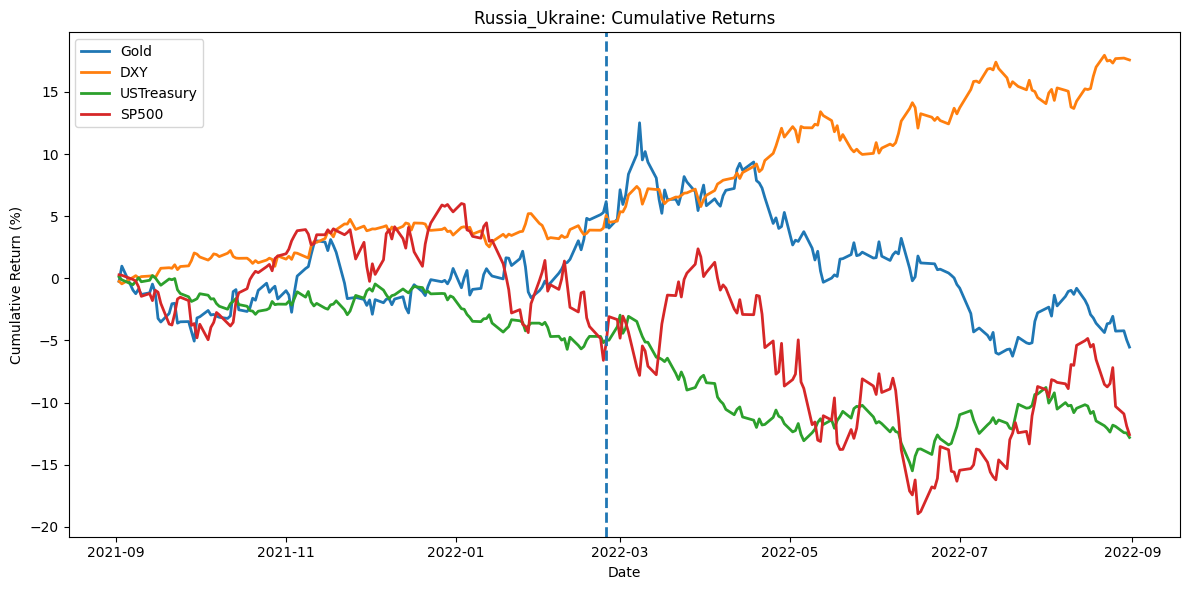

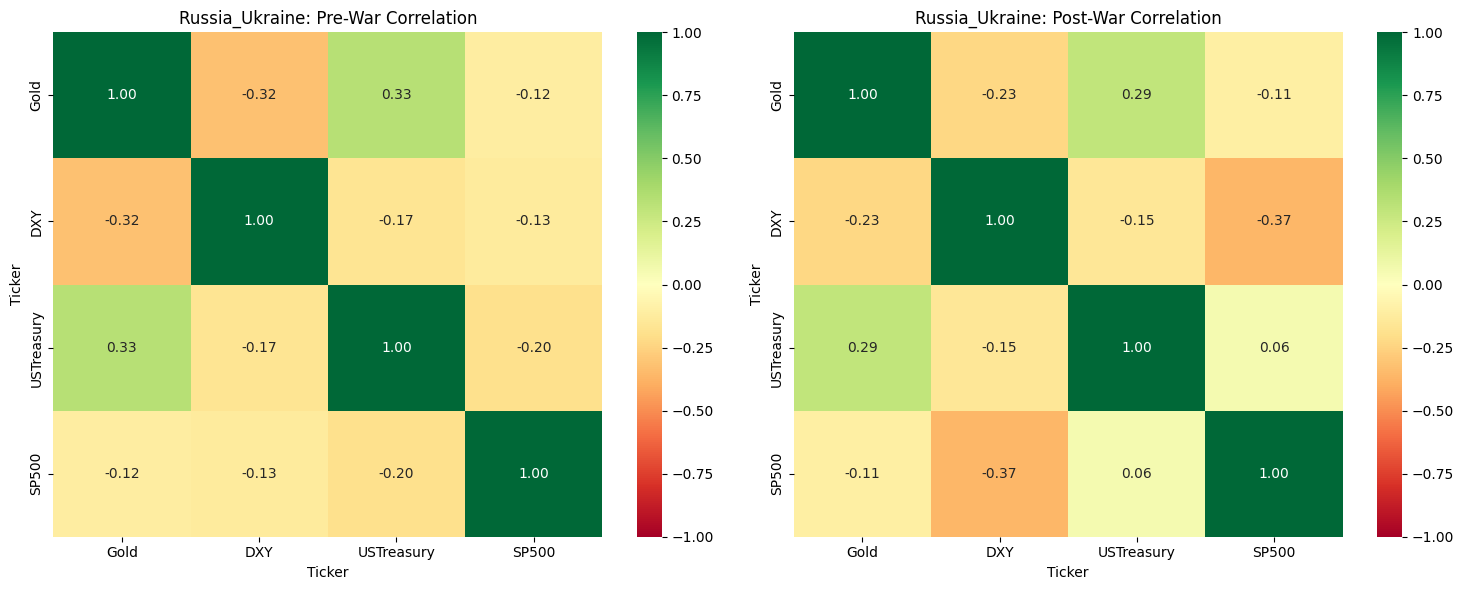


[S&P500 Correlation]
         Event      Asset  Pre_SP500_Correlation  Post_SP500_Correlation  Correlation_Change
Russia_Ukraine       Gold                -0.1164                 -0.1060              0.0104
Russia_Ukraine        DXY                -0.1287                 -0.3660             -0.2372
Russia_Ukraine USTreasury                -0.1952                  0.0593              0.2545


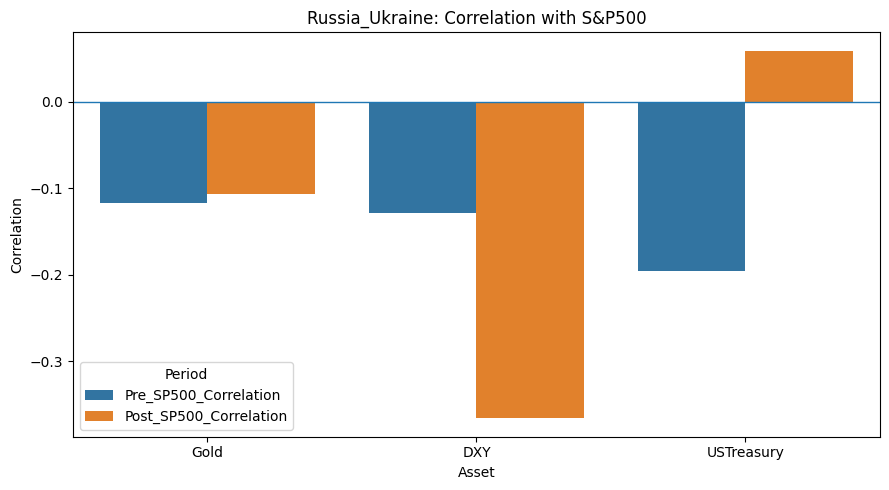


[VaR / Volatility]
         Event      Asset  VaR_Pre_95  VaR_Post_95  VaR_Risk_Change  Std_Pre  Std_Post
Russia_Ukraine       Gold     -1.6462      -1.6636           1.0578   0.8558    0.9639
Russia_Ukraine        DXY     -0.5009      -0.7863          56.9765   0.3351    0.5360
Russia_Ukraine USTreasury     -0.7353      -1.1241          52.8803   0.3984    0.6534


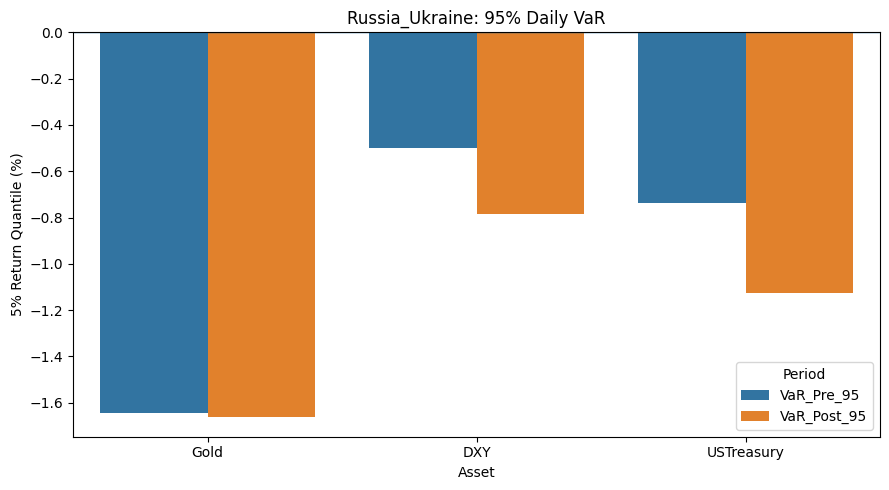

C:\Users\82109\AppData\Local\Temp\ipykernel_18824\2186388506.py:537: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  reg_data = pd.concat(



[OLS: Russia_Ukraine - Gold]
                            OLS Regression Results                            
Dep. Variable:                   Gold   R-squared:                       0.098
Model:                            OLS   Adj. R-squared:                  0.080
Method:                 Least Squares   F-statistic:                     4.492
Date:                Wed, 19 Aug 2026   Prob (F-statistic):           0.000618
Time:                        22:48:18   Log-Likelihood:                 835.73
No. Observations:                 251   AIC:                            -1659.
Df Residuals:                     245   BIC:                            -1638.
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
cons

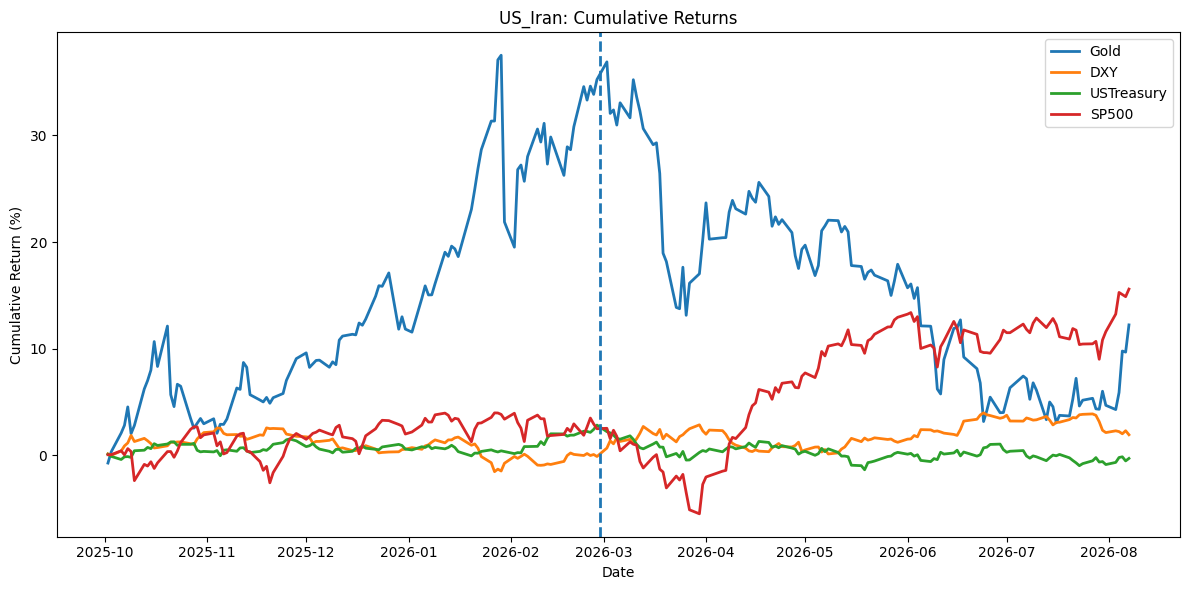

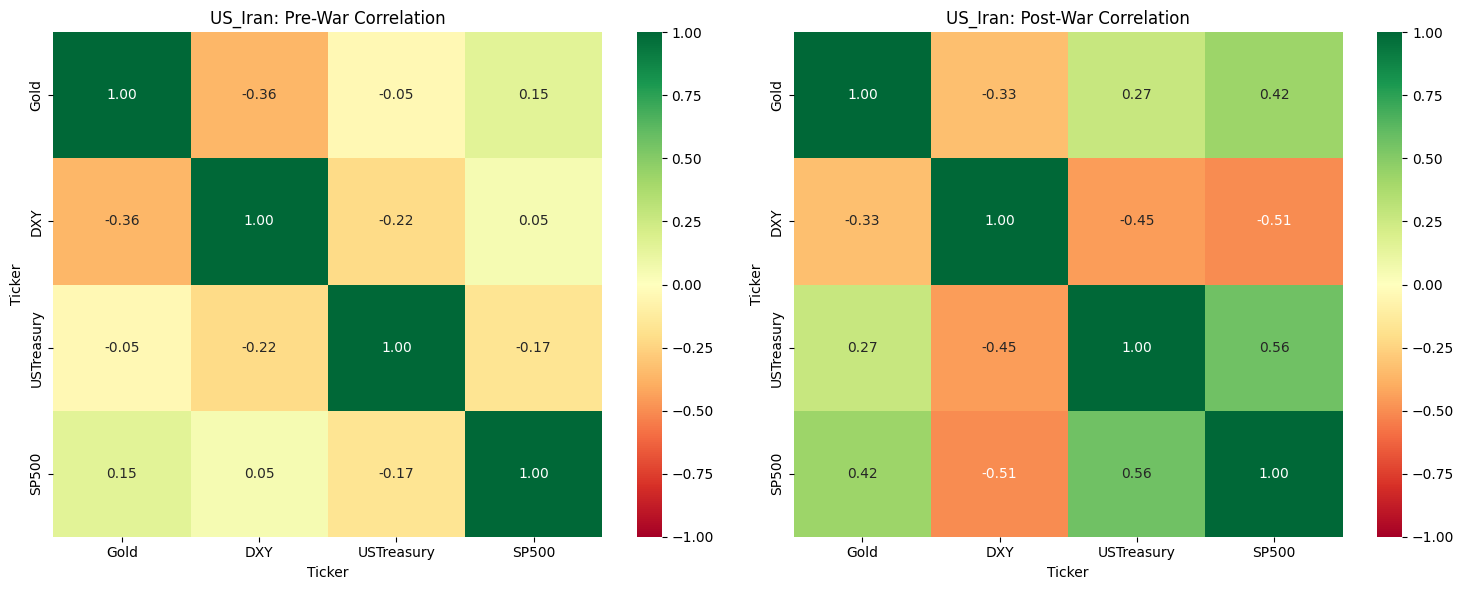


[S&P500 Correlation]
  Event      Asset  Pre_SP500_Correlation  Post_SP500_Correlation  Correlation_Change
US_Iran       Gold                 0.1539                  0.4221              0.2682
US_Iran        DXY                 0.0482                 -0.5069             -0.5551
US_Iran USTreasury                -0.1699                  0.5643              0.7342


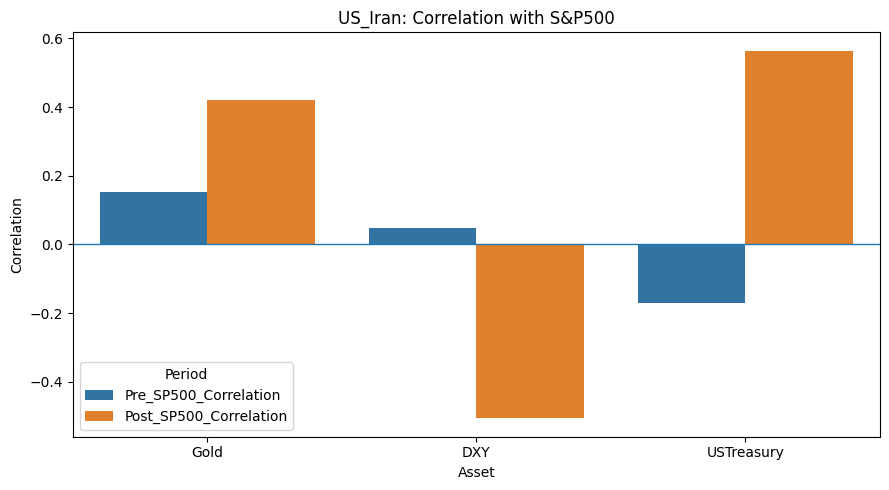


[VaR / Volatility]
  Event      Asset  VaR_Pre_95  VaR_Post_95  VaR_Risk_Change  Std_Pre  Std_Post
US_Iran       Gold     -2.7899      -3.2933          18.0448   2.1075    1.7411
US_Iran        DXY     -0.5617      -0.5612          -0.0832   0.3161    0.3460
US_Iran USTreasury     -0.3320      -0.5236          57.7060   0.2457    0.3294


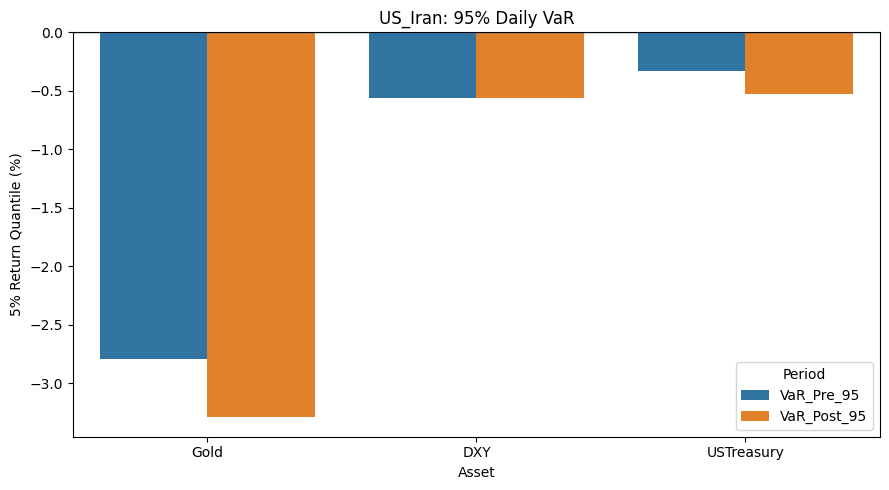

C:\Users\82109\AppData\Local\Temp\ipykernel_18824\2186388506.py:537: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  reg_data = pd.concat(



[OLS: US_Iran - Gold]
                            OLS Regression Results                            
Dep. Variable:                   Gold   R-squared:                       0.118
Model:                            OLS   Adj. R-squared:                  0.097
Method:                 Least Squares   F-statistic:                     6.663
Date:                Wed, 19 Aug 2026   Prob (F-statistic):           8.95e-06
Time:                        22:48:20   Log-Likelihood:                 548.96
No. Observations:                 212   AIC:                            -1086.
Df Residuals:                     206   BIC:                            -1066.
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const      

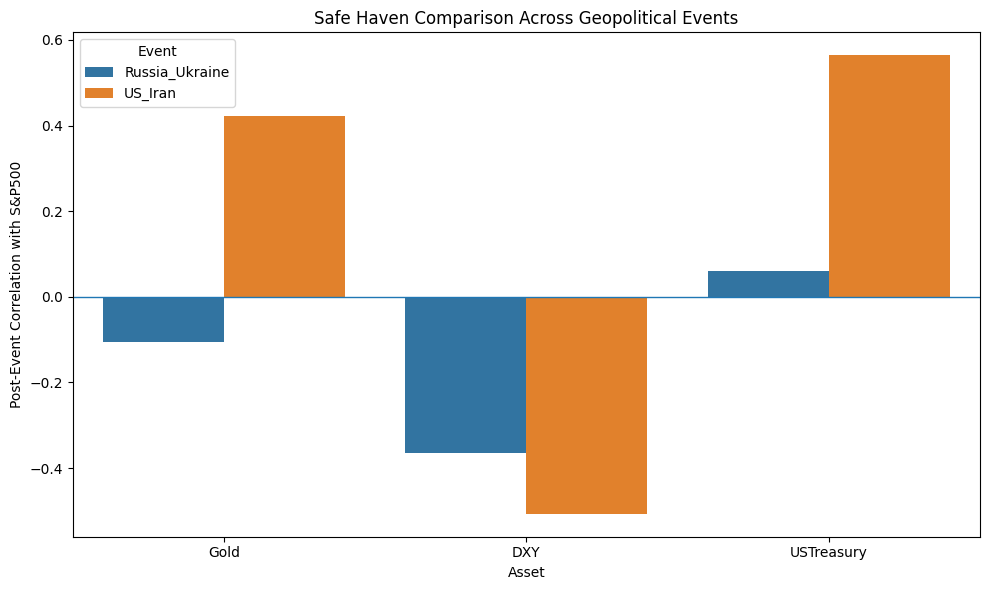


분석 완료


In [6]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm


# 1. 사건 설정

events = {
    "Russia_Ukraine": {
        "start_date": "2021-09-01",
        "end_date": "2022-09-01",
        "event_date": "2022-02-24"
    },
    "US_Iran": {
        "start_date": "2025-10-01",
        "end_date": "2026-08-10",
        "event_date": "2026-02-28"
    }
}


# 2. 변수 설정

safe_haven_tickers = {
    "Gold": "GC=F",
    "DXY": "DX-Y.NYB",
    "USTreasury": "IEF"
}

benchmark_tickers = {
    "SP500": "^GSPC"
}

macro_tickers = {
    "VIX": "^VIX",
    "US10Y": "^TNX"
}


# 3. 데이터 다운로드 함수

def download_prices(ticker_dict, start, end):

    data = yf.download(
        list(ticker_dict.values()),
        start=start,
        end=end,
        auto_adjust=False,
        progress=False
    )

    if data.columns.nlevels > 1:

        if "Adj Close" in data.columns.get_level_values(0):
            prices = data["Adj Close"]
        else:
            prices = data["Close"]

    else:
        prices = data.copy()

    ticker_to_name = {
        ticker: name
        for name, ticker in ticker_dict.items()
    }

    prices = prices.rename(columns=ticker_to_name)
    prices = prices[list(ticker_dict.keys())]

    return prices


# 4. VaR 계산 함수

def calculate_var(return_series, confidence_level=0.95):

    return np.percentile(
        return_series.dropna(),
        (1 - confidence_level) * 100
    )


# 5. 사건별 분석 함수

def analyze_event(
    event_name,
    start_date,
    end_date,
    event_date
):

    event_date = pd.to_datetime(event_date)

    print("\n")
    print("=" * 60)
    print(f"EVENT: {event_name}")
    print("=" * 60)


    # 6. 데이터 다운로드

    safe_prices = download_prices(
        safe_haven_tickers,
        start_date,
        end_date
    )

    benchmark_prices = download_prices(
        benchmark_tickers,
        start_date,
        end_date
    )

    macro_data = download_prices(
        macro_tickers,
        start_date,
        end_date
    )


    # 7. 로그수익률 계산

    safe_returns = np.log(
        safe_prices / safe_prices.shift(1)
    )

    benchmark_returns = np.log(
        benchmark_prices / benchmark_prices.shift(1)
    )

    asset_returns = pd.concat(
        [
            safe_returns,
            benchmark_returns
        ],
        axis=1
    ).dropna()


    # 8. 누적수익률 계산

    cum_returns = (
        np.exp(asset_returns.cumsum())
        - 1
    )


    # 9. VIX 및 금리 변화량 계산

    macro_changes = pd.DataFrame(
        index=macro_data.index
    )

    macro_changes["VIX_diff"] = (
        macro_data["VIX"].diff()
    )

    macro_changes["Rate_diff"] = (
        macro_data["US10Y"].diff()
    )


    # 10. 전쟁 전후 구분

    pre_war = asset_returns[
        asset_returns.index < event_date
    ]

    post_war = asset_returns[
        asset_returns.index >= event_date
    ]

    print("\n[Sample Size]")
    print("Pre-war:", len(pre_war))
    print("Post-war:", len(post_war))


    # 11. 평균수익률 및 변동성

    comparison_results = []

    for asset in safe_haven_tickers.keys():

        comparison_results.append({

            "Event": event_name,
            "Asset": asset,

            "Pre_Mean_Return":
                pre_war[asset].mean() * 100,

            "Post_Mean_Return":
                post_war[asset].mean() * 100,

            "Pre_Volatility":
                pre_war[asset].std() * 100,

            "Post_Volatility":
                post_war[asset].std() * 100

        })

    return_df = pd.DataFrame(
        comparison_results
    )

    print("\n[Return / Volatility]")

    print(
        return_df.round(4).to_string(
            index=False
        )
    )


    # 12. 누적수익률 시각화

    plt.figure(
        figsize=(12, 6)
    )

    for asset in asset_returns.columns:

        plt.plot(
            cum_returns.index,
            cum_returns[asset] * 100,
            label=asset,
            linewidth=2
        )

    plt.axvline(
        event_date,
        linestyle="--",
        linewidth=2
    )

    plt.title(
        f"{event_name}: Cumulative Returns"
    )

    plt.xlabel("Date")
    plt.ylabel("Cumulative Return (%)")

    plt.legend()
    plt.tight_layout()

    plt.savefig(
        f"{event_name}_cumulative_returns.png",
        dpi=300
    )

    plt.show()


    # 13. 전체 상관관계

    pre_corr = pre_war.corr()
    post_corr = post_war.corr()

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(15, 6)
    )

    sns.heatmap(
        pre_corr,
        annot=True,
        fmt=".2f",
        center=0,
        vmin=-1,
        vmax=1,
        cmap="RdYlGn",
        ax=axes[0]
    )

    axes[0].set_title(
        f"{event_name}: Pre-War Correlation"
    )

    sns.heatmap(
        post_corr,
        annot=True,
        fmt=".2f",
        center=0,
        vmin=-1,
        vmax=1,
        cmap="RdYlGn",
        ax=axes[1]
    )

    axes[1].set_title(
        f"{event_name}: Post-War Correlation"
    )

    plt.tight_layout()

    plt.savefig(
        f"{event_name}_correlation.png",
        dpi=300
    )

    plt.show()


    # 14. S&P500과의 상관관계

    correlation_results = []

    for asset in safe_haven_tickers.keys():

        pre_sp_corr = (
            pre_war[asset]
            .corr(pre_war["SP500"])
        )

        post_sp_corr = (
            post_war[asset]
            .corr(post_war["SP500"])
        )

        correlation_results.append({

            "Event":
                event_name,

            "Asset":
                asset,

            "Pre_SP500_Correlation":
                pre_sp_corr,

            "Post_SP500_Correlation":
                post_sp_corr,

            "Correlation_Change":
                post_sp_corr - pre_sp_corr

        })

    correlation_df = pd.DataFrame(
        correlation_results
    )

    print("\n[S&P500 Correlation]")

    print(
        correlation_df.round(4).to_string(
            index=False
        )
    )


    # 15. S&P500 상관관계 시각화

    corr_plot = correlation_df.melt(

        id_vars=[
            "Event",
            "Asset"
        ],

        value_vars=[
            "Pre_SP500_Correlation",
            "Post_SP500_Correlation"
        ],

        var_name="Period",

        value_name="Correlation"
    )

    plt.figure(
        figsize=(9, 5)
    )

    sns.barplot(
        data=corr_plot,
        x="Asset",
        y="Correlation",
        hue="Period"
    )

    plt.axhline(
        0,
        linewidth=1
    )

    plt.title(
        f"{event_name}: Correlation with S&P500"
    )

    plt.ylabel("Correlation")

    plt.tight_layout()

    plt.savefig(
        f"{event_name}_sp500_correlation.png",
        dpi=300
    )

    plt.show()


    # 16. VaR 및 변동성

    var_results = []

    for asset in safe_haven_tickers.keys():

        var_pre = calculate_var(
            pre_war[asset]
        )

        var_post = calculate_var(
            post_war[asset]
        )

        std_pre = (
            pre_war[asset].std()
        )

        std_post = (
            post_war[asset].std()
        )

        if var_pre != 0:

            risk_change = (
                abs(var_post)
                / abs(var_pre)
                - 1
            ) * 100

        else:

            risk_change = np.nan


        var_results.append({

            "Event":
                event_name,

            "Asset":
                asset,

            "VaR_Pre_95":
                var_pre * 100,

            "VaR_Post_95":
                var_post * 100,

            "VaR_Risk_Change":
                risk_change,

            "Std_Pre":
                std_pre * 100,

            "Std_Post":
                std_post * 100

        })


    var_df = pd.DataFrame(
        var_results
    )

    print("\n[VaR / Volatility]")

    print(
        var_df.round(4).to_string(
            index=False
        )
    )


    # 17. VaR 시각화

    var_plot = var_df.melt(

        id_vars=[
            "Event",
            "Asset"
        ],

        value_vars=[
            "VaR_Pre_95",
            "VaR_Post_95"
        ],

        var_name="Period",

        value_name="VaR"
    )

    plt.figure(
        figsize=(9, 5)
    )

    sns.barplot(
        data=var_plot,
        x="Asset",
        y="VaR",
        hue="Period"
    )

    plt.axhline(
        0,
        linewidth=1
    )

    plt.title(
        f"{event_name}: 95% Daily VaR"
    )

    plt.ylabel(
        "5% Return Quantile (%)"
    )

    plt.tight_layout()

    plt.savefig(
        f"{event_name}_var.png",
        dpi=300
    )

    plt.show()


    # 18. 회귀분석 데이터 구성

    reg_data = pd.concat(
        [
            asset_returns,
            macro_changes
        ],
        axis=1
    ).dropna()


    # 19. 전쟁 더미변수

    reg_data["War_Dummy"] = (
        reg_data.index >= event_date
    ).astype(int)


    # 20. VIX 상호작용 변수

    reg_data["VIX_War_Interaction"] = (
        reg_data["VIX_diff"]
        * reg_data["War_Dummy"]
    )


    # 21. 자산별 회귀분석

    regression_results = {}
    regression_summary = []

    for asset in safe_haven_tickers.keys():

        y = reg_data[asset]

        X = reg_data[
            [
                "SP500",
                "VIX_diff",
                "Rate_diff",
                "War_Dummy",
                "VIX_War_Interaction"
            ]
        ]

        X = sm.add_constant(X)

        model = sm.OLS(
            y,
            X
        ).fit(
            cov_type="HC3"
        )

        regression_results[
            asset
        ] = model

        print(
            f"\n[OLS: {event_name} - {asset}]"
        )

        print(
            model.summary()
        )


        for variable in model.params.index:

            regression_summary.append({

                "Event":
                    event_name,

                "Asset":
                    asset,

                "Variable":
                    variable,

                "Coefficient":
                    model.params[variable],

                "P_Value":
                    model.pvalues[variable]

            })


    regression_df = pd.DataFrame(
        regression_summary
    )


    # 22. 사건별 결과 저장

    return_df.to_csv(
        f"{event_name}_return_volatility.csv",
        index=False
    )

    correlation_df.to_csv(
        f"{event_name}_sp500_correlation.csv",
        index=False
    )

    var_df.to_csv(
        f"{event_name}_var.csv",
        index=False
    )

    regression_df.to_csv(
        f"{event_name}_regression.csv",
        index=False
    )


    return {
        "return": return_df,
        "correlation": correlation_df,
        "var": var_df,
        "regression": regression_df
    }


# 23. 두 사건 분석 실행

all_results = {}

for event_name, settings in events.items():

    all_results[event_name] = analyze_event(

        event_name=event_name,

        start_date=settings["start_date"],

        end_date=settings["end_date"],

        event_date=settings["event_date"]
    )


# 24. 두 사건 결과 통합

all_returns = pd.concat(
    [
        result["return"]
        for result in all_results.values()
    ],
    ignore_index=True
)

all_correlations = pd.concat(
    [
        result["correlation"]
        for result in all_results.values()
    ],
    ignore_index=True
)

all_var = pd.concat(
    [
        result["var"]
        for result in all_results.values()
    ],
    ignore_index=True
)

all_regressions = pd.concat(
    [
        result["regression"]
        for result in all_results.values()
    ],
    ignore_index=True
)


# 25. 두 사건 비교 출력

print("\n[Event Comparison - Return / Volatility]")

print(
    all_returns.round(4).to_string(
        index=False
    )
)


print("\n[Event Comparison - S&P500 Correlation]")

print(
    all_correlations.round(4).to_string(
        index=False
    )
)


print("\n[Event Comparison - VaR]")

print(
    all_var.round(4).to_string(
        index=False
    )
)


print("\n[Event Comparison - Regression]")

print(
    all_regressions.round(5).to_string(
        index=False
    )
)


# 26. 통합 결과 저장

all_returns.to_csv(
    "ALL_event_return_volatility.csv",
    index=False
)

all_correlations.to_csv(
    "ALL_event_sp500_correlation.csv",
    index=False
)

all_var.to_csv(
    "ALL_event_var.csv",
    index=False
)

all_regressions.to_csv(
    "ALL_event_regression.csv",
    index=False
)


# 27. 사건별 Safe Haven 상관관계 비교 그래프

comparison_plot = all_correlations[
    [
        "Event",
        "Asset",
        "Post_SP500_Correlation"
    ]
]

plt.figure(
    figsize=(10, 6)
)

sns.barplot(
    data=comparison_plot,
    x="Asset",
    y="Post_SP500_Correlation",
    hue="Event"
)

plt.axhline(
    0,
    linewidth=1
)

plt.title(
    "Safe Haven Comparison Across Geopolitical Events"
)

plt.ylabel(
    "Post-Event Correlation with S&P500"
)

plt.tight_layout()

plt.savefig(
    "ALL_event_safe_haven_comparison.png",
    dpi=300
)

plt.show()


print("\n분석 완료")